# 1 - From AnnData to spatial graphs

This vignette takes a public spatial-proteomics dataset from `squidpy`,
converts it into the inputs `grass-mil` expects, and builds the cellular
graphs the models train on.

**Dataset.** `squidpy.datasets.mibitof()` -- MIBI-TOF imaging of colorectal
carcinoma: 3 images, ~3,300 cells, 36 protein markers, 8 annotated cell types
(Hartmann et al.). It is a good fit because `grass-mil` is built for
cell-resolved spatial proteomics: every cell has coordinates, a type, and a
marker profile.

**What you need to supply.** `grass-mil` reads a *manifest* -- one row per
image -- pointing at per-sample files. Everything else is config.


## Setup

The vignettes need the `io` and `interpretability` extras, plus `squidpy` to
fetch the data. `squidpy` is only used here to download a public dataset; it
is not a runtime dependency of `grass-mil`.


In [1]:
# !pip install 'grass-mil[interpretability,io]' squidpy

import pathlib

import numpy as np
import pandas as pd
import squidpy as sq

WORK = pathlib.Path("vignette_work").resolve()
RAW = WORK / "data" / "raw"
PROCESSED = WORK / "data" / "processed"
RAW.mkdir(parents=True, exist_ok=True)
print("working directory:", WORK.name + "/")

/tmp/ci312/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


working directory: vignette_work/


## Load the public dataset

`squidpy` caches the download, so re-running is cheap.


In [2]:
adata = sq.datasets.mibitof()
print(adata)
print()
print("images :", sorted(adata.obs["library_id"].unique()))
print("donors :", sorted(adata.obs["donor"].unique()))
print("types  :", sorted(adata.obs["Cluster"].unique()))

AnnData object with n_obs × n_vars = 3309 × 36
    obs: 'row_num', 'point', 'cell_id', 'X1', 'center_rowcoord', 'center_colcoord', 'cell_size', 'category', 'donor', 'Cluster', 'batch', 'library_id'
    var: 'mean-0', 'std-0', 'mean-1', 'std-1', 'mean-2', 'std-2'
    uns: 'Cluster_colors', 'batch_colors', 'neighbors', 'spatial', 'umap'
    obsm: 'X_scanorama', 'X_umap', 'spatial'
    obsp: 'connectivities', 'distances'
    layers: None (.X)

images : ['point16', 'point23', 'point8']
donors : ['21d7', '90de']
types  : ['Endothelial', 'Epithelial', 'Fibroblast', 'Imm_other', 'Myeloid_CD11c', 'Myeloid_CD68', 'Tcell_CD4', 'Tcell_CD8']


## Reshape into the grass-mil input contract

Two conventions matter:

1. **One file per sample.** The manifest maps `sample_id` to a file, so we
   split the combined AnnData by `library_id`.
2. **Name the cell-type column `cell_type`.** Several defaults key off this
   name -- the sampler's `property_name`, the composition transform, and the
   interpretability `cell_type_column`. You can override all of them, but
   renaming once here is simpler.

We also densify `X`: the h5ad loader reads the matrix directly.


In [3]:
rows = []
for lib in sorted(adata.obs["library_id"].unique()):
    sub = adata[adata.obs["library_id"] == lib].copy()
    sub.X = np.asarray(sub.X.todense(), dtype=np.float32)
    sub.obs["cell_type"] = sub.obs["Cluster"].astype(str)
    sub.obs = sub.obs[["cell_type", "cell_size", "donor"]]
    path = RAW / f"{lib}.h5ad"
    sub.write_h5ad(path)
    rows.append(
        {
            "sample_id": lib,
            "input_path": path.name,  # resolved relative to the manifest
            "input_type": "h5ad",
            "region_id": lib,
            "donor": str(sub.obs["donor"].iloc[0]),
        }
    )

manifest = pd.DataFrame(rows)
manifest[["sample_id", "input_path", "input_type", "region_id"]].to_csv(
    RAW / "manifest.csv", index=False
)

# A bag-level label. See the caveat in vignette 2 before reading anything
# into supervised numbers on a three-image dataset.
manifest["donor_label"] = (manifest["donor"] == "21d7").astype(int)
manifest[["region_id", "donor_label"]].to_csv(RAW / "labels.csv", index=False)

manifest

,sample_id,input_path,input_type,region_id,donor,donor_label
0,point16,point16.h5ad,h5ad,point16,90de,0
1,point23,point23.h5ad,h5ad,point23,21d7,1
2,point8,point8.h5ad,h5ad,point8,90de,0


## Build the graphs

`prepare_data()` runs once and writes `.pt` graph files plus an index. The
settings worth understanding:

- **`coord_scale_um`** converts stored coordinates to micrometres. MIBI-TOF
  FOVs here are ~400 um across ~1024 px, so ~0.39 um/px. Getting this wrong
  silently rescales every distance downstream -- graph edges, ego-graph radii,
  and the filtration thresholds in the interpretability report.
- **`sample_unit=tile`** cuts each image into square patches. A patch is one
  graph unit, and later one MIL bag.
- **`tiling.tile_size_um=100`** gives ~16 patches per image at this scale.
- **`min_cells`** drops patches too sparse to form a useful graph.

Run it through the CLI so the exact command is reusable outside a notebook.


In [4]:
import subprocess
import os
import sys

cmd = [
    sys.executable,
    "-m",
    "grass_mil.train",
    "task=finetune_mean",
    "model=supervised_module",
    "data=spatial_omics",
    "trainer=cpu",
    f"data.raw_manifest_path={RAW}/manifest.csv",
    f"data.processed_dir={PROCESSED}",
    "data.h5ad.coord_source=obsm",
    "data.h5ad.coord_key=spatial",
    "data.h5ad.categorical_label_columns=[cell_type]",
    "data.coord_scale_um=0.39",
    "data.sample_unit=tile",
    "data.tiling.tile_size_um=100",
    "data.tiling.stride_um=100",
    "data.min_cells=20",
    "data.tiling.min_cells=20",
    f"data.graph_labels.label_file={RAW}/labels.csv",
    "data.graph_labels.id_column=region_id",
    "data.graph_labels.tasks=[donor_label]",
    "data.graph_labels.scope=region",
    "data.split.train_val_test_split=[0.34,0.33,0.33]",
    "data.split.split_by=sample",
    "data.force_precompute=true",
    f"paths.log_dir={WORK}/logs",
    "+trainer.fast_dev_run=true",  # precompute only; no real training here
]
env = dict(os.environ, PROJECT_ROOT=str(WORK))
out = subprocess.run(cmd, capture_output=True, text=True, env=env)
print("exit code:", out.returncode)
if out.returncode:
    print(out.stdout[-3000:], out.stderr[-3000:])

exit code: 0


## Inspect what was built


In [5]:
import json
import collections

index = json.loads((PROCESSED / "processed_index.json").read_text())
entries = index["entries"] if "entries" in index else index
meta = json.loads((PROCESSED / "metadata.json").read_text())

print("graph units (patches):", len(entries))
print("per sample :", dict(collections.Counter(e["sample_id"] for e in entries)))
print("per split  :", dict(collections.Counter(e["split"] for e in entries)))
print()
print("cell types :", meta["label_maps"]["cell_type"])
print(
    "markers    :",
    len(meta["molecular_feature_names"]),
    meta["molecular_feature_names"][:6],
    "...",
)

graph units (patches): 44
per sample : {'point16': 16, 'point23': 12, 'point8': 16}
per split  : {'test': 16, 'val': 12, 'train': 16}

cell types : {'Imm_other': 0, 'Tcell_CD4': 1, 'Endothelial': 2, 'Tcell_CD8': 3, 'Fibroblast': 4, 'Myeloid_CD11c': 5, 'Myeloid_CD68': 6, 'Epithelial': 7}
markers    : 36 ['ASCT2', 'ATP5A', 'CD11c', 'CD14', 'CD3', 'CD31'] ...


Note the split: whole images go to train/val/test. Splitting by `sample`
rather than by `patch` is deliberate -- patches from one image share a donor
and a batch, so a patch-level split would leak that identity across folds.


## Look at one graph unit

Each unit is a `torch_geometric.data.Data`: node features `x` (markers),
`edge_index` (Delaunay adjacency), `pos` (micrometre coordinates), and
`categorical_codes` (the cell-type index the encoder embeds).


In [6]:
import torch

sample_entry = entries[0]
g = torch.load(sample_entry["path"], weights_only=False)
print(g)
print()
print("nodes:", g.num_nodes, "| edges:", g.edge_index.shape[1])
print("x    :", tuple(g.x.shape))
print("pos  : extent", g.pos.min(0).values.tolist(), "to", g.pos.max(0).values.tolist(), "um")

Data(
  x=[59, 36],
  edge_index=[2, 322],
  pos=[59, 2],
  edge_attr=[322, 2],
  edge_attr_names=[2],
  categorical_codes=[59, 1],
  categorical_labels=[1],
  categorical_slices={ cell_type=0 },
  graph_y=[1, 1],
  graph_label_names=[1],
  sample_id='point16',
  region_id='point16',
  patch_id='point16_point16_patch_0'
)

nodes: 59 | edges: 322
x    : (59, 36)
pos  : extent [0.38999998569488525, 3.9000000953674316] to [98.66999816894531, 100.2300033569336] um


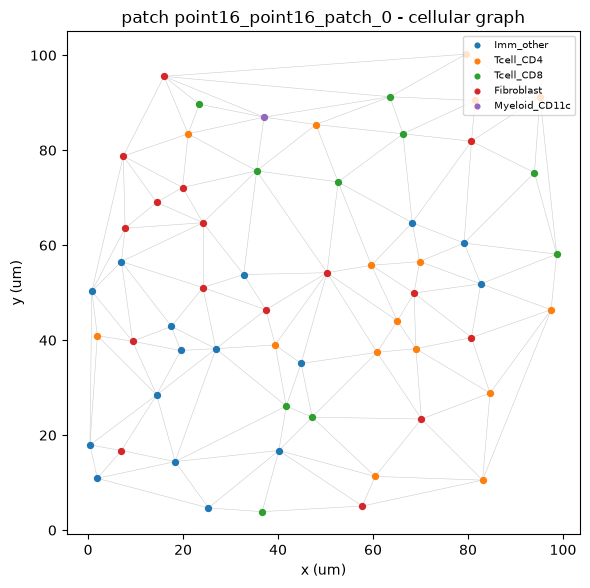

In [7]:
import matplotlib.pyplot as plt

inv = {v: k for k, v in meta["label_maps"]["cell_type"].items()}
codes = g.categorical_codes[:, 0].numpy()
pos = g.pos.numpy()

fig, ax = plt.subplots(figsize=(6, 6))
# Draw every edge: this is a Delaunay triangulation, and subsampling the
# edges would make it look like something else. edge_index stores both
# directions, so keep one per pair.
from matplotlib.collections import LineCollection

src, dst = g.edge_index.numpy()
keep = src < dst
segments = [[pos[s], pos[d]] for s, d in zip(src[keep], dst[keep])]
ax.add_collection(LineCollection(segments, linewidths=0.4, colors="0.8", zorder=1))
for c in np.unique(codes):
    m = codes == c
    ax.scatter(pos[m, 0], pos[m, 1], s=18, label=inv[int(c)], zorder=2)
ax.set_xlabel("x (um)")
ax.set_ylabel("y (um)")
ax.set_title(f"patch {sample_entry['patch_id']} - cellular graph")
ax.legend(fontsize=7, markerscale=0.8, loc="upper right")
ax.set_aspect("equal")
plt.tight_layout()

## Next

Vignette 2 pretrains an encoder on these graphs without labels, then uses the
learned embeddings to discover spatial niches.
